# **Mathématiques pour Machine Learning Project 2026-2027**

## _Requirements_

Over the course of this project, we will handle images, matrices, and graphs to understand oru results. For this purpose, it is mandatory to run the following cell, in order to install all the libraries. <br>
Be aware that this operation can take a while.

In [ ]:
#%pip install numpy pillow requests scikit-learn matplotlib pandas

## _Imports_

In [10]:
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import os
import io
import zipfile
import pandas as pd
from pathlib import Path


## 1. The MNIST Database

### 1.1 Retrieving the dataset

Import of the files from the github (https://github.com/mbornet-hl/MNIST/tree/master/IMAGES/GROUPS), normalization.

In [ ]:
cols, rows = 40, 25   # was (25, 40) before


file_path = "cleaned_mnist_filenames.txt"
with open(file_path, 'r') as file:
    content = file.read()
    filenames = [name.strip() for name in content.split(',') if name.strip()]

github_url = "https://github.com/mbornet-hl/MNIST/raw/master/IMAGES/GROUPS/"

x_list = []
y_list = []

for fname in filenames:
    label = int(fname.split('-')[1].split('_')[0])
    response = requests.get(github_url + fname)

    if response.status_code == 200:
        sheet = Image.open(BytesIO(response.content)).convert('L')
        cols, rows = 40, 25   # was (25, 40) before

        W, H = sheet.size     # 1920, 1080
        sheet_digit_w = W // cols   # 1920 // 40 = 48
        sheet_digit_h = H // rows   # 1080 // 25 = 43

        margin_x = (1920 - 40*28) // 2   # = 400px left margin
        margin_y = (1080 - 25*28) // 2   # = 190px top margin

        print(f"margin_x: {margin_x}, margin_y: {margin_y}")

        start_x, start_y = 300, 200
        end_x, end_y = 1730, 970

        cell_w = (end_x - start_x) / 40
        cell_h = (end_y - start_y) / 25

        for r in range(25):
            for c in range(40):
                # Calculate the four corners for this specific digit
                left   = start_x + (c * cell_w)
                top    = start_y + (r * cell_h)
                right  = left + cell_w
                bottom = top + cell_h

                # Crop the cell
                digit_crop = sheet.crop((left, top, right, bottom))

                # Resize to standard MNIST size (28x28)
                digit_crop = digit_crop.resize((28, 28), Image.Resampling.LANCZOS)

                # Convert to 0-1 range and INVERT
                # MNIST expects black background (0) and white drawing (1)
                vec = 1-(np.array(digit_crop).flatten() / 255.0)
                x_list.append(vec)
                y_list.append(label)

    else:
        print(f"Failed: {fname}")

X = np.array(x_list)
y = np.array(y_list)
print(X.shape)   # should be (63000, 784)
print(y.shape)   # should be (63000,)

### 1.2 Dataset splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_train[:5])
print(y_train[:5])
print(X_test[:5])
print(y_test[:5])

### 1.3 Classification Model

In [11]:
# =============================================================================
# 1. SOFTMAX
# =============================================================================
# For a score vector o of size 10:
#   P_k = e^{o_k} / sum_j e^{o_j}
#
# Numerical trick: subtract max(o) before exponentiating to avoid overflow.
# This doesn't change the result since:
#   e^{o_k} / sum e^{o_j} = e^{o_k - c} / sum e^{o_j - c}  for any c

def softmax(o):
    """
    Compute softmax probabilities.

    Args:
        o : np.ndarray of shape (n, 10) — score matrix (one row per sample)

    Returns:
        P : np.ndarray of shape (n, 10) — probability matrix
    """
    # Subtract max per row for numerical stability
    o_stable = o - np.max(o, axis=1, keepdims=True)
    exp_o = np.exp(o_stable)
    P = exp_o / np.sum(exp_o, axis=1, keepdims=True)
    return P

In [40]:
# =============================================================================
# 2. ONE-HOT ENCODING
# =============================================================================
# Converts a label vector y of shape (n,) with values in {0,...,9}
# into a matrix Y of shape (n, 10) where Y[i, y[i]] = 1, rest = 0.

def one_hot(y, num_classes=10):
    """
    Args:
        y           : np.ndarray of shape (n,) — integer labels
        num_classes : int

    Returns:
        Y : np.ndarray of shape (n, num_classes)
    """
    n = len(y)
    Y = np.zeros((n, num_classes))
    Y[np.arange(n), y] = 1
    return Y

In [ ]:
# =============================================================================
# 3. CROSS-ENTROPY LOSS
# =============================================================================
# L = - (1/n) * sum_i sum_k  y_i^(k) * ln(P_k(x_i))
#
# Since y is one-hot, only the term k = y_i survives:
#   L = - (1/n) * sum_i ln(P_{y_i}(x_i))
#
# We clip P to avoid log(0)

def cross_entropy_loss(P, Y):
    """
    Args:
        P : np.ndarray of shape (n, 10) — predicted probabilities
        Y : np.ndarray of shape (n, 10) — one-hot true labels

    Returns:
        loss : float — scalar cross-entropy loss
    """
    n = P.shape[0]
    # Clip to avoid log(0)
    P_clipped = np.clip(P, 1e-12, 1.0)
    loss = 0

    for i in range(n):
        for k in range(10):
            loss += Y[i][k] * np.log(P_clipped[i][k])
            
    return loss*(-1/n)

In [ ]:
# =============================================================================
# 4. FORWARD PASS
# =============================================================================
# Given weights A (10x784) and biases b (10,):
#   o = X @ A.T + b      shape: (n, 10)
#   P = softmax(o)       shape: (n, 10)

def forward(X, A, b):
    """
    Args:
        X : np.ndarray of shape (n, 784) — input data
        A : np.ndarray of shape (10, 784) — weight matrix
        b : np.ndarray of shape (10,) — bias vector

    Returns:
        o : np.ndarray of shape (n, 10) — scores (logits)
        P : np.ndarray of shape (n, 10) — probabilities
    """
    o = X @ A.T + b      # (n, 784) @ (784, 10) + (10,) = (n, 10)
    P = softmax(o)
    return o, P

In [12]:
# =============================================================================
# 5. GRADIENTS
# =============================================================================
# From the derivation:
#
#   dL/dA = (1/n) * (P - Y).T @ X       shape: (10, 784)
#   dL/db = (1/n) * sum_i (P - Y)_i     shape: (10,)
#
# where (P - Y) has shape (n, 10).

def compute_gradients(X, P, Y):
    """
    Args:
        X : np.ndarray of shape (n, 784)
        P : np.ndarray of shape (n, 10) — predicted probabilities
        Y : np.ndarray of shape (n, 10) — one-hot true labels

    Returns:
        dA : np.ndarray of shape (10, 784)
        db : np.ndarray of shape (10,)
    """
    n = X.shape[0]
    diff = P - Y                          # (n, 10)  — "prediction minus truth"
    dA = (diff.T @ X) / n                 # (10, n) @ (n, 784) = (10, 784)
    db = np.sum(diff, axis=0) / n         # (10,)
    return dA, db

In [ ]:
# =============================================================================
# 6. GRADIENT DESCENT
# =============================================================================

def gradient_descent(X_train, y_train, learning_rate=0.1, n_epochs=100):
    """
    Train the linear model using full-batch gradient descent.

    Args:
        X_train       : np.ndarray of shape (n, 784)
        y_train       : np.ndarray of shape (n,) — integer labels
        learning_rate : float
        n_epochs      : int

    Returns:
        A      : np.ndarray of shape (10, 784) — trained weights
        b      : np.ndarray of shape (10,) — trained biases
        losses : list of float — loss at each epoch
    """
    n, d = X_train.shape     # n = nb samples, d = 784
    num_classes = 10

    # --- Initialization: small random weights, zero biases ---
    # We use small values to avoid saturation of softmax at the start
    rng = np.random.default_rng(seed=42)
    A = np.zeros((10,d))   # (10, 784)
    b = np.zeros(num_classes)                         # (10,)

    # One-hot encode labels once
    Y_train = one_hot(y_train, num_classes)           # (n, 10)

    losses = []

    for epoch in range(n_epochs):
        # --- Forward pass ---
        _, P = forward(X_train, A, b)

        # --- Loss ---
        loss = cross_entropy_loss(P, Y_train)
        losses.append(loss)

        # --- Gradients ---
        dA, db = compute_gradients(X_train, P, Y_train)

        # --- Parameter update ---
        A = A - learning_rate * dA
        b = b - learning_rate * db

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

    return A, b, losses

In [ ]:
# =============================================================================
# 7. PREDICTION & ERROR RATE
# =============================================================================

def predict(X, A, b):
    """
    Returns predicted class for each sample.

    Args:
        X : np.ndarray of shape (n, 784)
        A : np.ndarray of shape (10, 784)
        b : np.ndarray of shape (10,)

    Returns:
        y_hat : np.ndarray of shape (n,) — predicted labels
    """
    _, P = forward(X, A, b)
    y_hat = np.argmax(P, axis=1)
    return y_hat


def error_rate(y_true, y_pred):
    """
    Returns the fraction of misclassified samples.
    """
    return np.mean(y_true != y_pred)

In [ ]:
# =============================================================================
# 8. MAIN
# =============================================================================

if __name__ == "__main__":
    # --- Load your data here ---


    # --- Train ---
    from sklearn.preprocessing import LabelBinarizer
    lb = LabelBinarizer()
    Y_train = lb.fit_transform(y_train)   # (42210, 10)
    Y_test  = lb.transform(y_test)        # (20790, 10)
    
    
    A, b, losses = gradient_descent(
        X_train, y_train,
        learning_rate=0.01,
        n_epochs=30
    )

    # --- Evaluate ---
    y_pred_train = predict(X_train, A, b)
    y_pred_test  = predict(X_test,  A, b)

    print(f"\nError rate on TRAIN set : {error_rate(y_train, y_pred_train)*100:.2f}%")
    print(f"Error rate on TEST  set : {error_rate(y_test,  y_pred_test) *100:.2f}%")


In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Multi-Layer Classification

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_diff(x):
    return (x > 0).astype(float)

def softmax(o):
    exp_o = np.exp(o - np.max(o))  # numerical stability
    return exp_o / np.sum(exp_o)

In [ ]:
class Neuron:
    def __init__(self, input_size):
        # Parameters
        self.weights = np.random.randn(input_size) * 0.01
        self.bias = 0.0
        
        # Gradients (for backprop)
        self.dW = np.zeros_like(self.weights)
        self.db = 0.0

In [ ]:
class Layer :
    def __init__(self, input_size, numberNeurons, activation="relu"):
        self.neurons = [Neuron(input_size) for _ in range(numberNeurons)]
        self.activation = activation
        
        # Stored values for backprop
        self.z = None
        self.o = None
        self.delta = None
        
        
    """
    in inputs: the layer of inputs. If it is a layer of neurons, we pass the values of the neurons 
    """
    def forward(self, inputs, is_output=False):
        o = []
        
        for neuron in self.neurons:
            o_i = np.dot(neuron.weights, inputs) + neuron.bias
            o.append(o_i)
        
        o = np.array(o)
        self.o = o
        
        # Activation
        if is_output:
            self.z = softmax(o)
        else:
            if self.activation == "relu":
                self.z = relu(o)
            else:
                raise ValueError("Unsupported activation")
        
        return self.z

In [ ]:
def vect_of(y, num_classes=10):
    v = np.zeros(num_classes)
    v[y] = 1
    return v

def cross_entropy(y_hat, y):
    y_vec = vect_of(y)
    return -np.sum(y_vec * np.log(y_hat + 1e-15))  # avoid log(0)

In [ ]:
def forward_network(x, layers):
    current = x
    
    for i, layer in enumerate(layers):
        o = []
        
        for neuron in layer.neurons:
            o_i = np.dot(neuron.weights, current) + neuron.bias
            o.append(o_i)
        
        o = np.array(o)
        layer.o = o  # store for backprop
        
        # activation
        if i == len(layers) - 1:
            # OUTPUT LAYER → softmax
            z = softmax(o)
        else:
            z = relu(o)
        
        layer.z = z  # store
        current = z
        
    return current  # final prediction

In [ ]:
def backward_network(x, y, layers, lr):
    y_vec = vect_of(y)
    
    L = len(layers)
    
    # OUTPUT LAYER 
    last = layers[-1]
    delta = last.z - y_vec   # diff cross entropy / softmax
    
    last.delta = delta
    
    # gradients for last layer
    prev_z = layers[-2].z if L > 1 else x
    
    for i, neuron in enumerate(last.neurons):
        neuron.dW = delta[i] * prev_z
        neuron.db = delta[i]
    
    # HIDDEN LAYERS 
    for h in reversed(range(L - 1)):
        current = layers[h]
        next_layer = layers[h + 1]
        
        delta_new = []
        
        for i, neuron in enumerate(current.neurons):
            # sum over next layer
            s = 0
            for j, next_neuron in enumerate(next_layer.neurons):
                s += next_layer.delta[j] * next_neuron.weights[i]
            
            d = s * relu_diff(current.z[i])
            delta_new.append(d)
        
        delta_new = np.array(delta_new)
        current.delta = delta_new
        
        prev_z = layers[h-1].z if h > 0 else x
        
        for i, neuron in enumerate(current.neurons):
            neuron.dW = delta_new[i] * prev_z
            neuron.db = delta_new[i]
    
    # UPDATE 
    for layer in layers:
        for neuron in layer.neurons:
            neuron.weights -= lr * neuron.dW
            neuron.bias   -= lr * neuron.db

In [ ]:
# Network architecture 
input_size = 784
hidden_size = 128
output_size = 10

# 1 LAYER
# layer1 = Layer(input_size, output_size)

# layers = [layer1]

# 2 LAYERS
layer1 = Layer(input_size, hidden_size)
layer2 = Layer(hidden_size, output_size)

layers = [layer1, layer2]



In [ ]:
def train(X, y, layers, epochs=5, lr=0.01):
    n = X.shape[0]
    
    for epoch in range(epochs):
        total_loss = 0
        
        for i in range(n):
            x = X[i]
            label = y[i]
            
            # Forward
            y_hat = forward_network(x, layers)
            
            # Loss
            loss = cross_entropy(y_hat, label)
            total_loss += loss
            
            # Backward + update
            backward_network(x, label, layers, lr)
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/n:.4f}")

In [ ]:
def predict(x, layers):
    probs = forward_network(x, layers)
    return np.argmax(probs)

def accuracy(X, y, layers):
    correct = 0
    
    for i in range(len(X)):
        pred = predict(X[i], layers)
        if pred == y[i]:
            correct += 1
    
    return correct / len(X)

In [ ]:
train(X_train, y_train, layers, epochs=5, lr=0.01)

In [ ]:
W1 = np.array([neuron.weights for neuron in layer1.neurons])
W2 = np.array([neuron.weights for neuron in layer2.neurons])

b1 = np.array([neuron.bias for neuron in layer1.neurons])
b2 = np.array([neuron.bias for neuron in layer2.neurons])

In [ ]:
def predict_batch(X, layers):
    y_pred = []
    for x in X:
        pred = predict(x, layers)
        y_pred.append(pred)
    return np.array(y_pred)

In [ ]:
train_acc = accuracy(X_train, y_train, layers)
test_acc = accuracy(X_test, y_test, layers)

y_pred_train = [predict(x, layers) for x in X_train]
y_pred_test = [predict(x, layers) for x in X_test]
# 
# y_pred_train_vect = [vect_of(y) for y in y_pred_train]
# y_pred_test_vect = [vect_of(y) for y in y_pred_test]

print("Train accuracy:", train_acc*100, "%")
print("Test accuracy:", test_acc*100, "%")

print(f"Train error: {np.mean(y_train != y_pred_train)*100:.2f}%")
print(f"Test  error: {np.mean(y_test  != y_pred_test )*100:.2f}%")

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# MISCLASSIFIED

y_pred_test = predict_batch(X_test, layers)
misclassified_idx = np.where(y_pred_test != y_test)[0]

print(f"Misclassified test samples: {len(misclassified_idx)}")

n_plot = min(30, len(misclassified_idx))
fig, axes = plt.subplots(3, 10, figsize=(12, 5))

for ax, idx in zip(axes.flat, misclassified_idx[:n_plot]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"true:{y_test[idx]} pred:{y_pred_test[idx]}")
    ax.axis('off')

for ax in axes.flat[n_plot:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Part 2

In [13]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [14]:
# Labels 
label_converter = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [15]:
# Get all the data 
all_dictionaries = []
for i in range(5):
    all_dictionaries.append(unpickle(f"cifar-10-batches-py/data_batch_{i+1}"))

In [16]:
# Few settings to understand the code easily 
number_of_line = 32
size_of_line = 32
position_red_color = 0
position_green_color = 1024
position_blue_color = 2*1024

def get_red_pixel(image, pixel, line_pointer):
    return image[pixel+ line_pointer * size_of_line + position_red_color]

def get_green_pixel(image, pixel, line_pointer):
    return image[pixel + line_pointer * size_of_line +position_green_color]

def get_blue_pixel(image, pixel, line_pointer):
    return image[pixel + line_pointer * size_of_line +position_blue_color]

Shape for the 10 image (10, 3072)
Shape for a converted image (10, 32, 32, 3)


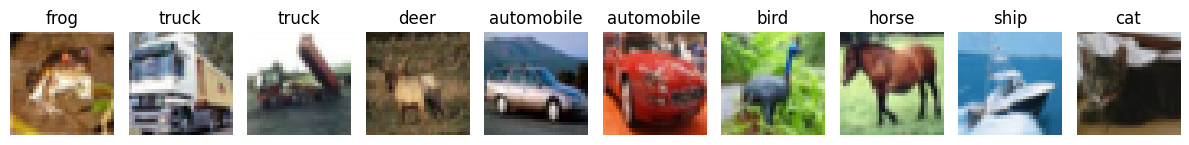

In [8]:
# Display some images 
ten_images = all_dictionaries[0][b'data'][:10]
ten_images_labels = all_dictionaries[0][b'labels'][:10]

print("Shape for the 10 image", ten_images.shape) #3072 = 32x32x3 

# Convert each image in a 32x32x3 array 
converted_images = []
for image in ten_images:
    new_image = []
    for line_pointer in range(number_of_line):
        line = []
        for pixel_pointer in range(size_of_line):
            line.append([get_red_pixel(image, pixel_pointer, line_pointer), get_green_pixel(image, pixel_pointer, line_pointer), get_blue_pixel(image, pixel_pointer, line_pointer)])
        new_image.append(line)
    converted_images.append(new_image)

converted_images = np.array(converted_images)
print("Shape for a converted image", converted_images.shape)


fig, axes = plt.subplots(1, 10, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(converted_images[i])
    ax.set_title(label_converter[ten_images_labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
def to_gray_scale(image):
    new_image = []
    for line_pointer in range(number_of_line):
        for pixel_pointer in range(size_of_line):
            pixel = 0.299 * get_red_pixel(image, pixel_pointer, line_pointer) + 0.587 * get_green_pixel(image, pixel_pointer, line_pointer) + 0.114 * get_blue_pixel(image, pixel_pointer, line_pointer)
            new_image.append(pixel)
    return np.array(new_image)

In [ ]:
# Display 30 images in gray scale 

ten_images = all_dictionaries[0][b'data'][:30]
ten_images_labels = all_dictionaries[0][b'labels'][:30]



fig, axes = plt.subplots(3, 10, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(to_gray_scale(ten_images[i]).reshape(32, 32), cmap='gray')
    ax.set_title(label_converter[ten_images_labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [52]:
total_X_train = []
total_y_train = []
for dictionary in all_dictionaries:
    X_train = dictionary[b'data']
    y_train = dictionary[b'labels']
    
    total_X_train.append(X_train)
    total_y_train .append(y_train)

X_train_color = np.array(total_X_train).reshape(-1, 3072)
y_train = np.array(total_y_train).reshape(-1)


test_dictionary = unpickle("cifar-10-batches-py/test_batch")
X_test_color = np.array(test_dictionary[b'data'])
y_test = np.array(test_dictionary[b'labels'])

X_train = []
X_test = []

for image in X_train_color:
    X_train.append(to_gray_scale(image))

for image in X_test_color:
    X_test.append(to_gray_scale(image))

X_train = np.array(X_train)
X_test = np.array(X_test)

In [ ]:
X_train_color

In [ ]:
X_train = X_train/255
X_test = X_test/255
A, b, losses = gradient_descent(
    X_train, y_train,
    learning_rate=0.01,
    n_epochs=30
)

# --- Evaluate ---
y_pred_train = predict(X_train, A, b)
y_pred_test  = predict(X_test,  A, b)

print(f"\nError rate on TRAIN set : {error_rate(y_train, y_pred_train)*100:.2f}%")
print(f"Error rate on TEST  set : {error_rate(y_test,  y_pred_test) *100:.2f}%")

In [ ]:
# Network architecture 
input_size = 1024
hidden_size = 128
output_size = 10

# 1 LAYER
# layer1 = Layer(input_size, output_size)

# layers = [layer1]

# 2 LAYERS
layer1 = Layer(input_size, hidden_size)
layer2 = Layer(hidden_size, output_size)

layers = [layer1, layer2]


train(X_train, y_train, layers, epochs=5, lr=0.01)


train_acc = accuracy(X_train, y_train, layers)
test_acc = accuracy(X_test, y_test, layers)

y_pred_train = [predict(x, layers) for x in X_train]
y_pred_test = [predict(x, layers) for x in X_test]
# 
# y_pred_train_vect = [vect_of(y) for y in y_pred_train]
# y_pred_test_vect = [vect_of(y) for y in y_pred_test]

print("Train accuracy:", train_acc*100, "%")
print("Test accuracy:", test_acc*100, "%")

print(f"Train error: {np.mean(y_train != y_pred_train)*100:.2f}%")
print(f"Test  error: {np.mean(y_test  != y_pred_test )*100:.2f}%")

### Conclusion on the usage of our model with the cirfa10 in gray scale

We see that a simple neural network with no hidden layers is useless. Indeed, with gray scale we have 90% of error meaning that the model is pure random. Only one guess out of 10 is true.

We 2 hidden layers, the model seems to be a bit more precise but is still not enough. With an error rate of 72%, we clearly understand that the whole model is flawed. But we understand that increasing the quantity of layers and neurons affected the overall accuracy of the model.

The quality of the model on gray scale is quite disappointing and really far what the article mentioned.

## Models with the colored images

In [ ]:
# Simple architecture

X_train_color = X_train_color/255
X_test_color = X_test_color/255
A, b, losses = gradient_descent(
    X_train_color, y_train,
    learning_rate=0.01,
    n_epochs=30
)

# --- Evaluate ---
y_pred_train = predict(X_train_color, A, b)
y_pred_test  = predict(X_test_color,  A, b)

print(f"\nError rate on TRAIN set : {error_rate(y_train, y_pred_train)*100:.2f}%")
print(f"Error rate on TEST  set : {error_rate(y_test,  y_pred_test) *100:.2f}%")

In [ ]:
# Network architecture
input_size = 3072
hidden_size = 128
output_size = 10

# 1 LAYER
# layer1 = Layer(input_size, output_size)

# layers = [layer1]

# 2 LAYERS
layer1 = Layer(input_size, hidden_size)
layer2 = Layer(hidden_size, output_size)

layers = [layer1, layer2]


train(X_train_color, y_train, layers, epochs=5, lr=0.01)


train_acc = accuracy(X_train_color, y_train, layers)
test_acc = accuracy(X_test_color, y_test, layers)

y_pred_train = [predict(x, layers) for x in X_train_color]
y_pred_test = [predict(x, layers) for x in X_test_color]
#
# y_pred_train_vect = [vect_of(y) for y in y_pred_train]
# y_pred_test_vect = [vect_of(y) for y in y_pred_test]

print("Train accuracy:", train_acc*100, "%")
print("Test accuracy:", test_acc*100, "%")

print(f"Train error: {np.mean(y_train != y_pred_train)*100:.2f}%")
print(f"Test  error: {np.mean(y_test  != y_pred_test )*100:.2f}%")

### Conclusion on the usage of our model with the cirfa10 in color scale

The color scale greatly increased the quality of the models.

First, for the simple neural network, the accuracy went from 10% to 28%. The simple model with color has the same performance as the model with two hidden layers working with gray scale.

Next, for the model with 2 hidden layers, we are surprised to see we don't have much improvement compared to the one layer one since it is also at 30% of accuracy.

We can conclude that working with more information such as for example the colors is greatly improving the capacities of the model. We also note that launching the program with colored pictures takes a big amount of time: ~14 min

But again, we are still far from the error rates mentioned in the article

# Feature maps

## Analysis of feature map on a gray scale image

In [19]:
# Open the image with PILLOW and get its array

cat_image = Image.open("cat.png").convert("L")
width, height,  = cat_image.size
array_cat_image = np.asarray(cat_image)
print(array_cat_image.shape)

(3024, 4032)


In [20]:
# Add a contour of 0
def add_contour(array_image):
    height, width = array_image.shape
    line_of_zeros = np.zeros(width)
    col_of_zeros = np.zeros((height +2, 1))

    array_image = np.insert(array_image,0, line_of_zeros, axis=0)
    array_image = np.insert(array_image, len(array_image), line_of_zeros, axis=0)
    array_image = np.insert(array_image, 0, 0, axis = 1)
    array_image = np.insert(array_image, len(array_image[0]), 0, axis = 1)
    return array_image

In [ ]:
array_cat_image = add_contour(array_cat_image)

In [ ]:
# Define different filters to test on the cat

K1 = 1/9* np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

K2 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

K3 = np.array([
    [-1, 2, -1],
    [-1, 2, -1],
    [-1, 2, -1]
])

K4 = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

K5 = np.array([
    [-1, 0, 1],
    [-1, 0, 2],
    [-1, 0, 1]
])

K6 = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
])

In [21]:
def result_filter(array_image, line, column, filter, bias):
    crop = array_image[line-1:line+2, column-1:column+2]
    result = np.multiply(crop, filter)
    return result.sum() + bias

In [ ]:
test = np.array([
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5]
])

filter = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])
print(result_filter(test, 1, 1, filter, 2))

In [14]:
def apply_filter(array_image, filter, bias):
    height_image, width_image = array_image.shape
    width_image -=2
    height_image -= 2
    array_new_image = np.zeros((height_image, width_image))
    for i in range(height_image):
        for j in range(width_image):
            array_new_image[i][j] = result_filter(array_image, i+1, j+1, filter, bias)
    return array_new_image



In [ ]:
K = [K1, K2, K3, K4, K5, K6]
for i in range(1, 7):
    print(i)
    after_filter = apply_filter(array_cat_image, K[i-1], 0)
    image_after_filter = Image.fromarray(after_filter)
    image_after_filter = image_after_filter.convert('L')
    image_after_filter.save(f"saves/result K{i}.png")

## Examination of the different filters

K1

K2

K3

K4

K5

K6


In [22]:
def apply_filter_rgb(array_image, filters, bias):
    RGB, height_image, width_image = array_image.shape
    width_image -=2
    height_image -= 2
    array_new_image = np.zeros((height_image, width_image))
    for i in range(height_image):
        for j in range(width_image):
            r = result_filter(array_image[0], i+1, j+1, filters[0], 0)
            g = result_filter(array_image[1], i+1, j+1, filters[1], 0)
            b = result_filter(array_image[2], i+1, j+1, filters[2], 0)
            array_new_image[i][j] = r+g+b+bias
    return array_new_image

In [23]:
def apply_filter_rgb_fast(array_image, filter, bias):
    RGB, height_image, width_image = array_image.shape
    width_image -=2
    height_image -= 2

    windows = np.lib.stride_tricks.sliding_window_view(array_image[0], (3, 3))
    outputR = np.sum(windows * filter[0], axis=(-2, -1))

    windows = np.lib.stride_tricks.sliding_window_view(array_image[1], (3, 3))
    outputG = np.sum(windows * filter[1], axis=(-2, -1))

    windows = np.lib.stride_tricks.sliding_window_view(array_image[2], (3, 3))
    outputB = np.sum(windows * filter[2], axis=(-2, -1))

    output = np.sum(np.array([outputR, outputG, outputB]), axis=0)
    output = output + bias
    return output

In [24]:
def apply_3D_filters_vectorized(array_image, filter_3d, bias):

    # windows shape is : height-2, width-2, 3, 3. The (-2) are canceled by the contour of 0
    windows = np.lib.stride_tricks.sliding_window_view(array_image, (3, 3))
    windows_expanded = windows[:, :, np.newaxis, :, :]
    filters_expanded = filter_3d[np.newaxis, np.newaxis, :, :, :]
    result = windows_expanded * filters_expanded
    output = np.sum(result, axis=(-3, -2, -1))

    return output + bias

In [25]:
def max_pooling(array_image):
    height, width = array_image.shape
    height//=2
    width//=2
    array_new_image = np.zeros((height, width))
    for i in range(height):
        for j in range(width):
            array_new_image[i][j] = max(array_image[2*i-1][2*j-1], array_image[2*i][2*j-1], array_image[2*i-1][2*j], array_image[2*i][2*j])
    return array_new_image

Definition of the different filters to start the learning

In [53]:
#64 simple filters
filter1 = np.random.rand(64, 3, 3, 3)
bias1 = np.random.rand(64)

#64 3D filter with each filter being of size 64x3x3
filter2 = np.random.rand(64, 64, 3, 3)
bias2 = np.random.rand(64)

#64 3D filter with each filter being of size 64x3x3
filter3 = np.random.rand(64, 64, 3, 3)
bias3 = np.random.rand(64)

#64 3D filter with each filter being of size 64x3x3
filter4 = np.random.rand(64, 64, 3, 3)
bias4 = np.random.rand(64)

weights = np.random.rand(4096, 10)
bias5 = np.random.rand(10)


Definition of the process

In [54]:
#Change the dimension of the images to 3x32x32 to separate each RGB
X_train_color = X_train_color.reshape(-1, 3, 32, 32)
X_test_color = X_test_color.reshape(-1, 3, 32, 32)

# For now we will work with only 100 images
X_train_color = X_train_color[:100]
y_train = y_train[:100]
y_train = one_hot(y_train)

#Put the images through the simple filters after adding a contour

step1 = []
for array_image in X_train_color:
    image_result = []
    new_array_image = []
    for i in range(3):
        new_array_image.append(add_contour(array_image[i]))
    new_array_image = np.array(new_array_image)
    for i in range(len(filter1)):
        image_result.append(apply_filter_rgb_fast(new_array_image, filter1[i], bias1[i]))
    step1.append(image_result)

step1 = np.array(step1)
print(step1.shape)

(100, 64, 32, 32)


In [55]:
step2 = []
for array_image in step1:
    image_result= []
    for i in range(len(array_image)):
        new_array_image = add_contour(array_image[i])
        image_result.append(apply_3D_filters_vectorized(new_array_image, filter2[i], bias2[i]))
    step2.append(image_result)
step2 = np.array(step2)
print(step2.shape)

(100, 64, 32, 32)


In [56]:
step3 = []
for array_image in step2:
    image_result = []
    for i in range(len(array_image)):
        image_result.append(max_pooling(array_image[i]))
    step3.append(image_result)

step3 = np.array(step3)
print(step3.shape)

(100, 64, 16, 16)


In [57]:
step4 = []
for array_image in step3:
    image_result= []
    for i in range(len(array_image)):
        new_array_image = add_contour(array_image[i])
        image_result.append(apply_3D_filters_vectorized(new_array_image, filter3[i], bias3[i]))
    step4.append(image_result)
step4 = np.array(step4)
print(step4.shape)

(100, 64, 16, 16)


In [58]:
step5 = []
for array_image in step4:
    image_result = []
    for i in range(len(array_image)):
        image_result.append(max_pooling(array_image[i]))
    step5.append(image_result)

step5 = np.array(step5)
print(step5.shape)

(100, 64, 8, 8)


In [59]:
step6 = []
for array_image in step5:
    image_result= []
    for i in range(len(array_image)):
        new_array_image = add_contour(array_image[i])
        image_result.append(apply_3D_filters_vectorized(new_array_image, filter4[i], bias4[i]))
    step6.append(image_result)
step6 = np.array(step6)
print(step6.shape)

(100, 64, 8, 8)


In [60]:
flattened_array = step6.reshape(step6.shape[0], -1)
o = flattened_array @ weights + bias5
probability = softmax(o)

print(probability)


[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0.

In [68]:
learning_rate = 0.1

da , db = compute_gradients(flattened_array, probability, y_train)
weights = weights - learning_rate* da.T
bias5 = bias5 - learning_rate*db


In [ ]:
#Gradient on the 4th filter
part_gradient = (probability - y_train) @ weights.T
part_gradient = test.reshape(-1, 64, 8, 8)

step5_contour = []

for image in step5:
    image_result = []
    for i in range(len(image)):
        image_result.append(add_contour(image[i]))
    step5_contour.append(image_result)

step5_contour = np.array(step5_contour)
windows = np.lib.stride_tricks.sliding_window_view(step5_contour, (8, 8), axis=(2, 3))
windows_aligned = windows[:,:, ::-1, ::-1, :, :]
dK6 = np.sum(part_gradient[:,:, np.newaxis, np.newaxis, :, :] * windows_aligned, axis=(-2, -1))


image = Image.fromarray(array_cat_image)
image.show()

# **PART 3 - CBIS-DDSM**

It's important to note that we can't unzip **163** GB of images. For this we use libraries to extract info from a zip file without unzipping it

In [ ]:
"""
STEP 1
"""
# Config path
# make sure name match (normalement dans le github c'est file.zip)
ZIP_FILENAME = "file.zip"

ZIP_PATH = Path(ZIP_FILENAME)
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Could not find {ZIP_FILENAME} in your directory.")

print("Found local ZIP archive.")


"""
STEP 2 & 3 — Load Datasets Directly from inside the ZIP Archive
"""
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    # Read the training CSV directly out of the zip archive's 'csv/' folder asked in the project
    with z.open("csv/mass_case_description_train_set.csv") as f:
        df_mass = pd.read_csv(f)

print(f"Successfully extracted and loaded CSV from inside the ZIP.")
print(f"Training Cases: {df_mass.shape[0]} rows")


# Apply binary label mapping (Benign = 0, Malignant = 1)
# we combine benign and benign_without_callback
def encode_label(pathology: str) -> int:
    if pathology in ("BENIGN", "BENIGN_WITHOUT_CALLBACK"):
        return 0
    elif pathology == "MALIGNANT":
        return 1
    else:
        raise ValueError(f"Unexpected pathology value: {pathology!r}")

df_mass["label"] = df_mass["pathology"].apply(encode_label)


"""
STEP 4 — Build a Global Fast Lookup Map of the Actual ZIP Layout
"""
print("Indexing actual files inside ZIP")
zip_jpeg_lookup = {}

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for internal_path in z.namelist():
        # Only index items within the jpeg/ directory that end with .jpg or .jpeg
        if internal_path.startswith("jpeg/") and internal_path.lower().endswith(('.jpg', '.jpeg')):
            # internal_path looks like: jpeg/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1-172.jpg
            # We want to extract just the folder name part (the SeriesUID)
            parts = internal_path.split('/')
            if len(parts) >= 3:
                series_uid = parts[1]
                zip_jpeg_lookup[series_uid] = internal_path

print(f"ZIP indexing complete. Found {len(zip_jpeg_lookup)} active image directories.")


"""
STEP 5 & 6 Stream images directly out of the ZIP into arrays
"""
IMG_SIZE = (128, 128)
x_list = []
y_list = []
skipped = 0

print(f"\nStreaming images out of ZIP at {IMG_SIZE[0]}×{IMG_SIZE[1]}...")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for i, row in df_mass.iterrows():
        raw_csv_path = row["image file path"]

        if pd.isna(raw_csv_path):
            skipped += 1
            continue

        # Standardize slashes to avoid OS discrepancies
        clean_path = str(raw_csv_path).replace('\\', '/').strip()

        # Strip potential leading/trailing artifacts or root prefixes
        if clean_path.startswith("CBIS-DDSM/"):
            clean_path = clean_path.replace("CBIS-DDSM/", "", 1)

        # Example split: ['Mass-Training_P_00001_LEFT_CC', '1.3.6...994', '1.3.6...515', '000000.dcm']
        path_parts = clean_path.split('/')

        internal_zip_path = None

        # Try finding a match using the third element (index 2: the true SeriesInstanceUID)
        if len(path_parts) >= 3:
            series_uid = path_parts[2]
            internal_zip_path = zip_jpeg_lookup.get(series_uid)

        # Fallback check: try using the second element (index 1: StudyInstanceUID) just in case
        if not internal_zip_path and len(path_parts) >= 2:
            study_uid = path_parts[1]
            internal_zip_path = zip_jpeg_lookup.get(study_uid)

        # Final Fallback check: check if it matches using the alternate cropped column layout
        if not internal_zip_path:
            alt_path = str(row.get("cropped image file path", "")).replace('\\', '/').strip()
            alt_parts = alt_path.split('/')
            if len(alt_parts) >= 3:
                internal_zip_path = zip_jpeg_lookup.get(alt_parts[2])

        if not internal_zip_path:
            skipped += 1
            continue

        try:
            # read bytes from zip archive directory directly into RAM
            with z.open(internal_zip_path) as file_in_zip:
                img_bytes = file_in_zip.read()

            # convert raw image bytes to Grayscale matrix
            img = Image.open(io.BytesIO(img_bytes)).convert("L")

            # resize 128x128
            img = img.resize(IMG_SIZE, Image.Resampling.LANCZOS)

            # normalization [0,1]
            arr = np.array(img, dtype=np.float32) / 255.0

            # append flatten array
            x_list.append(arr.flatten())
            y_list.append(row["label"])

        except Exception as e:
            skipped += 1
            continue

# Final conversions to numpy arrays
X_medical = np.array(x_list, dtype=np.float32)
y_medical = np.array(y_list, dtype=np.int32)

print(f"\nProcess completed successfully!")

# check if import problem
print(f"Loaded: {len(x_list)} rows | Skipped: {skipped}")

# verify good shape
print(f"X array structure shape: {X_medical.shape}")
print(f"y array structure shape: {y_medical.shape}")


# Last step, split and stratify
"""
Because we have a small ratio difference between malignant and not malignant, we stratify = we make sure there is same number of malignant in training and tesintg
"""
if len(X_medical) > 0:
    X_train_med, X_test_med, y_train_med, y_test_med = train_test_split(
        X_medical, y_medical,
        test_size=0.2,
        random_state=42,
        stratify=y_medical
    )
    print(f"\nTraining subset size: {X_train_med.shape[0]} arrays")
    print(f"Testing subset size: {X_test_med.shape[0]} arrays")
    print("Preprocessing complete. Dataset arrays ready for network")
else:
    print("\nDataset is still empty. Error in extraction zip file")




In [ ]:
def plot_mammogram_grid(df, lookup_index, zip_filename, num_images=8):
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.flatten()

    plotted_count = 0

    with zipfile.ZipFile(zip_filename, 'r') as z:
        for idx, row in df.iterrows():
            if plotted_count >= num_images:
                break

            raw_path = row["image file path"]
            clean_path = str(raw_path).replace('\\', '/').strip()
            path_parts = clean_path.split('/')

            if len(path_parts) >= 3:
                series_uid = path_parts[2]
                internal_zip_path = lookup_index.get(series_uid)

                if internal_zip_path:
                    try:
                        with z.open(internal_zip_path) as file_in_zip:
                            img = Image.open(io.BytesIO(file_in_zip.read())).convert("L")

                        # Downsample slightly just for visual display speed
                        img = img.resize((256, 256))

                        ax = axes[plotted_count]
                        ax.imshow(img, cmap='gray')

                        label_str = "Malignant" if row["label"] == 1 else "Benign"
                        ax.set_title(f"{row['patient_id']} ({label_str})", fontsize=10)
                        ax.axis('off')

                        plotted_count += 1
                    except Exception:
                        continue # Skip corrupted entries gracefully

    # Hide any remaining empty subplots if the loop exited early
    for i in range(plotted_count, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the function to display 8 sample scans
plot_mammogram_grid(df_mass, zip_jpeg_lookup, ZIP_FILENAME, num_images=8)
